## **PAIR ASSIGNMENT**

Please work in pairs for this exercise. Pair up with the person next to you. If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand, and I will assist in pairing you with someone.


### **Task 0: Please assign your full name and your partner's full name to the variables below, respectively.**


Example:

```
your_name = 'Taylor Swift'
your_partner_name = 'Travis Kelce'
```


In [ ]:
# Assign your and your partner's name(s) here.  If you find that there isn't anyone sitting next to you or if you're unable to form a pair, please raise your hand.
# If, in the end, we are unable to find a partner for you, please assign the word "self" to the `your_partner_name` variable.
your_name = 'Jonathan Cruz'
your_partner_name = ''

## **K-NN**

In this notebook, you will review the k-NN algorithm and implement it from scratch **without relying on scikit-learn's pre-built implementations of these algorithms**.

The manual approach allows for a deeper understanding of the algorithms' workings and serves as an excellent way to understand what goes on behind the scenes when we use pre-built implementations from libraries such as scikit-learn.


Fun fact: In AI/ML/DS interviews, candidates are often asked to implement some of the most common ML algorithms from scratch to demonstrate a solid understanding of the algorithm.






### **Import Libraries and Load the Dataset**

In this exercise we will work with the wine dataset from scikit-learn library. Below is how you can load a dataset from scikit-learn.

In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, shuffle=True, random_state=42
)

### **Implementation of the Euclidean distance function**

* The Euclidean distance function for n-dimensional points.

In [2]:
def euclidean_distance(point1, point2):
  """
    Calculate the Euclidean distance between two points in n-dimensional space.

    Parameters:
    - point1 (array-like): The first point, represented as an iterable of numerical values.
    - point2 (array-like): The second point, represented as an iterable of numerical values.

    Returns:
    - float: The Euclidean distance between point1 and point2.

    Note:
    The two points must have the same dimensionality.
  """
  return np.sqrt(np.sum((point1 - point2) ** 2))

 ### **TASK 1: Review the implementation of a k-NN classifier from scratch.**

 * This function has been implemented to find the k-nearest neighbors of a specified data point. Review this implementation carefully and ensure you fully understand it in collaboration with your partner.

In [3]:
def get_k_nearest_neighbors(X_train, test_point, k):
  """
    Identify the indices of the k-nearest neighbors of a given test point from a set of training points.

    Parameters:
    - X_train (array-like): A collection of training points, where each point is represented as an iterable of numerical values.
    - test_point (array-like): The test point for which the k-nearest neighbors need to be found, represented as an iterable of numerical values.
    - k (int): The number of nearest neighbors to retrieve.

    Returns:
    - array-like: Indices of the k-nearest training points to the test point.

    Note:
    Uses the Euclidean distance to compute the proximity between points.
  """
  # distances is the array of distances between a test point and every point in the training set
  distances = [euclidean_distance(test_point, train_point) for train_point in X_train] # notice the call to the function euclidian_distance()


  # np.argsort() is particularly useful in algorithms like k-NN where
  # we want to find the indices of the nearest neighbors (smallest distances)
  # without actually sorting the entire distance array.
  k_nearest = np.argsort(distances)[:k]
  return k_nearest

### **TASK 2: Write a function to predict the class of a given data point using k-NN based on majority voting.**

In [ ]:
def predict(X_train, y_train, test_point, k):
  """
    Predict the label of a given test point based on the majority label of its k-nearest neighbors.

    Parameters:
    - X_train (array-like): A collection of training points, where each point is represented as an iterable of numerical values.
    - y_train (array-like): Labels corresponding to the training points.
    - test_point (array-like): The test point for which the label needs to be predicted, represented as an iterable of numerical values.
    - k (int): The number of nearest neighbors to consider for prediction.

    Returns:
    - int or str: Predicted label for the test point based on majority voting among its k-nearest neighbors.

    Note:
    In case of a tie (i.e., multiple labels having the same count among the k-nearest neighbors), the label returned is based on the order in the data.
  """
  # write your code here
  indices = get_k_nearest_neighbors(X_train, test_point, k)
  labels = [y_train[i] for i in indices]
  counts = {}
  for x in labels:
      counts[x] = counts.get(x, 0) + 1

  max_count = max(counts.values())
  tied_labels = {x for x, c in counts.items() if c == max_count}

   # for ties
  for x in labels:
      if x in tied_labels:
          return x

### **TASK 3: Implement function to perform k-NN and evaluate its performance.**

In [ ]:
import matplotlib.pyplot as plt

def eval_with_scores(X_train, Y_train, X_test, Y_test, k):
    """
    Evaluates the performance of the k-NN algorithm using and returns accuracy scores.

    Parameters:
    - X_train (array-like): Features of the training dataset.
    - Y_train (array-like): Target labels corresponding to the training dataset.
    - X_test (array-like): Features of the testing dataset.
    - Y_test (array-like): Target labels corresponding to the testing dataset.
    - k (int): Number of nearest neighbors to consider for the k-NN prediction.

    Returns:
    - float: Accuracy score of the k-NN algorithm on the test dataset (number correct divided by total number of predictions).

    Note:
    The function internally uses the `predict` function for k-NN prediction.
    """
    correct_predictions = 0
    total_predictions = len(X_test)

    # Your code here
    for i in range(total_predictions):
        label = predict(X_train, Y_train, X_test[i], k)
        if label == Y_test[i]:
            correct_predictions += 1
    return float(correct_predictions) / total_predictions

### **Visualize**

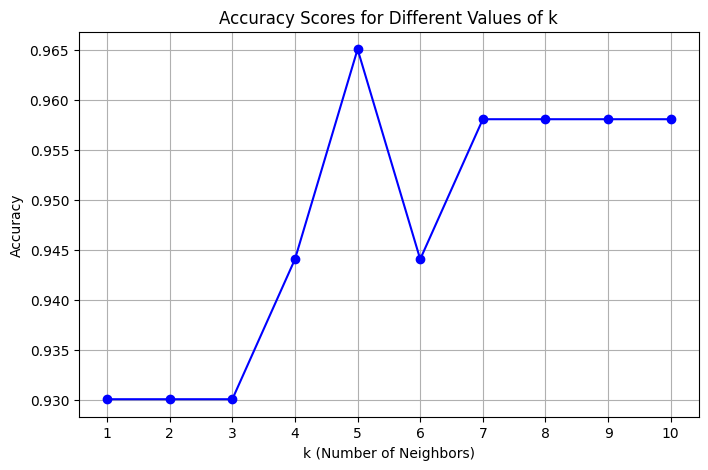

In [8]:
scores_per_k = {}

# Call the modified eval function for different values of k
for k in range(1, 11):
    accuracy = eval_with_scores(X_train, y_train, X_test, y_test, k)
    scores_per_k[k] = accuracy


# Plot the results
plt.figure(figsize=(8, 5))
plt.plot(list(scores_per_k.keys()), list(scores_per_k.values()), marker='o', linestyle='-', color='b')
plt.title('Accuracy Scores for Different Values of k')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.xticks(range(1, 11))
plt.grid(True)
plt.show()